# Problema 4 — Otimização mista da rede hidráulica

Este notebook apresenta a implementação do **Problema 4**, no qual existe um número limitado de canos grossos, de menor resistência hidráulica, e é necessário decidir em quais arestas da rede eles devem ser instalados.

A métrica otimizada é a maior pressão nodal da rede. Como a pressão de saída é prescrita, a menor pressão deixa de ser uma variável de projeto e passa a ser uma condição de contorno conhecida. Assim, o objetivo computacional é

\[
\min \; p^{\max}
\qquad \text{com} \qquad
p_i\leq p^{\max},\; i\in V.
\]

A apresentação contém três estudos computacionais:

1. **Caso 1:** rede com 20 nós, usada para mostrar a resolução por MILP;
2. **Caso 2:** rede com 100 nós e poucas arestas, mantendo o problema maior, mas tratável;
3. **Caso 3:** mesmo tipo de formulação com limite de tempo artificialmente muito baixo, mostrando que o código retorna a melhor solução viável encontrada ou uma solução heurística de fallback.


## 1. Importações

Para este notebook funcionar, o arquivo `ProblemaP4.py` deve estar dentro da pasta `src/` do projeto. A versão corrigida da classe já minimiza diretamente a pressão máxima da rede.


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import pandas as pd
except ImportError:
    pd = None

project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.ProblemGeneratorP1 import ProblemaP1Generator
from src.ProblemaP4 import ProblemaP4

## 2. Funções auxiliares da apresentação

As funções abaixo reduzem repetição no notebook. Elas geram uma rede, resolvem o P1 de referência, resolvem o P4 e exibem tabelas comparativas.

In [20]:
def gerar_rede(seed, num_nodes, edge_prob):
    generator = ProblemaP1Generator(seed=seed)
    p1 = generator.generate(
        num_nodes=num_nodes,
        edge_prob=edge_prob,
        mu=1e-3,
        patm=0.0,
        q_mode="uniform",
        single_sink=True,
    )
    p1.setup()
    p1.solve()
    return p1


def mostrar_resumo_p1(p1, nome):
    print(nome)
    print("numero de nos:", p1.num_nodes)
    print("numero de arestas:", p1.num_edges)
    print("pressao minima p1:", float(np.min(p1.p)), "Pa")
    print("pressao maxima p1:", float(np.max(p1.p)), "Pa")
    print("amplitude de pressao p1:", float(np.max(p1.p) - np.min(p1.p)), "Pa")


import math

def calcular_numero_canos_grossos(num_edges, thick_pipe_fraction=0.10, rounding="ceil"):
    if num_edges <= 0:
        raise ValueError("num_edges deve ser positivo")

    if not 0 <= thick_pipe_fraction <= 1:
        raise ValueError("thick_pipe_fraction deve estar entre 0 e 1")

    raw_value = thick_pipe_fraction * num_edges

    if rounding == "ceil":
        n_thick = math.ceil(raw_value)
    elif rounding == "floor":
        n_thick = math.floor(raw_value)
    elif rounding == "round":
        n_thick = round(raw_value)
    else:
        raise ValueError("rounding deve ser 'ceil', 'floor' ou 'round'")

    if thick_pipe_fraction > 0:
        n_thick = max(1, n_thick)

    return min(int(n_thick), int(num_edges))


def resolver_caso_p4(
    p1,
    nome,
    time_limit,
    mip_rel_gap=1e-4,
    disp=False,
    thick_pipe_fraction=0.10,
    thick_pipe_rounding="ceil",
    max_thick_pipes=None,
):
    if max_thick_pipes is None:
        n_thick_pipes = calcular_numero_canos_grossos(
            num_edges=p1.num_edges,
            thick_pipe_fraction=thick_pipe_fraction,
            rounding=thick_pipe_rounding,
        )
    else:
        n_thick_pipes = int(max_thick_pipes)

    p4 = ProblemaP4(
        p1_instance=p1,
        max_thick_pipes=n_thick_pipes,
        thick_area_factor=2.0,
        use_exact_number=True,
        pressure_bound_factor=5.0,
        big_m_factor=1.05,
        solver_options={
            "disp": disp,
            "time_limit": time_limit,
            "mip_rel_gap": mip_rel_gap,
        },
    )

    baseline = p4.evaluate_configuration(thick_edges=[])
    summary = p4.solve_milp(accept_feasible=True, use_fallback=True)

    comparison = {
        "caso": ["todos finos", "p4 otimizado"],
        "nos": [p1.num_nodes, p1.num_nodes],
        "arestas": [p1.num_edges, p1.num_edges],
        "canos_grossos": [0, summary["n_thick_used"]],
        "pressao_minima_pa": [baseline["pressure_min"], summary["pressure_min"]],
        "pressao_maxima_pa": [baseline["pressure_max"], summary["objective_pressure_max"]],
        "amplitude_pressao_pa": [baseline["pressure_range"], summary["pressure_range"]],
    }

    reduction = (
        (baseline["pressure_max"] - summary["objective_pressure_max"])
        / baseline["pressure_max"]
        * 100
    )

    print(nome)
    print("numero de arestas:", p1.num_edges)
    print("fracao de canos grossos:", thick_pipe_fraction)
    print("numero de canos grossos:", n_thick_pipes)
    print("status da solucao:", summary["solution_status"])
    print("solucao otima certificada:", summary["solution_is_optimal"])
    print("mensagem do solver:", summary["solver_message"])
    print("gap mip:", summary["mip_gap"])
    print("reducao percentual da pressao maxima:", reduction, "%")
    print("arestas grossas selecionadas:", summary["selected_thick_edges"])

    if pd is not None:
        comparison_df = pd.DataFrame(comparison)
        display(comparison_df)
    else:
        print(comparison)

    return p4, baseline, summary

## 3. Caso 1 — rede com 20 nós

Este caso é usado para apresentar a solução por otimização mista em uma rede de tamanho pequeno/médio. Ele mantém a ideia dos testes anteriores: poucos canos grossos são escolhidos entre todas as arestas disponíveis.

In [21]:
p1_20 = gerar_rede(
    seed=42,
    num_nodes=20,
    edge_prob=0.10,
)

mostrar_resumo_p1(p1_20, "caso 1: rede com 20 nos")

caso 1: rede com 20 nos
numero de nos: 20
numero de arestas: 35
pressao minima p1: 0.0 Pa
pressao maxima p1: 0.3048756532124219 Pa
amplitude de pressao p1: 0.3048756532124219 Pa


In [22]:
p4_20, baseline_20, summary_20 = resolver_caso_p4(
    p1=p1_20,
    nome="caso 1: p4 com 20 nos",
    time_limit=300,
    mip_rel_gap=1e-4,
    disp=False,
)

caso 1: p4 com 20 nos
numero de arestas: 35
fracao de canos grossos: 0.1
numero de canos grossos: 4
status da solucao: otima
solucao otima certificada: True
mensagem do solver: Optimization terminated successfully. (HiGHS Status 7: Optimal)
gap mip: 0.0
reducao percentual da pressao maxima: 66.6076954739959 %
arestas grossas selecionadas: [('node_1', 'node_5'), ('node_4', 'node_5'), ('node_7', 'node_17'), ('node_15', 'node_17')]


,caso,nos,arestas,canos_grossos,pressao_minima_pa,pressao_maxima_pa,amplitude_pressao_pa
0,todos finos,20,35,0,0.0,0.304876,0.304876
1,p4 otimizado,20,35,4,0.0,0.101805,0.101805


### 3.1. Arestas escolhidas no caso de 20 nós

In [23]:
edge_rows_20 = p4_20.edge_solution_table()

if pd is not None:
    edge_df_20 = pd.DataFrame(edge_rows_20)
    display(edge_df_20.sort_values(["x_grosso", "edge"], ascending=[False, True]))
else:
    for row in edge_rows_20:
        print(row)

,edge,tipo_cano,x_grosso,area_original,area_usada,length,condutancia_usada,delta_pressao,vazao
5,"(node_1, node_5)",grosso,1,1.4017,2.8034,3.83,81.645359,0.035715,2.915959
32,"(node_15, node_17)",grosso,1,0.7114,1.4228,4.21,19.132237,-0.032170,-0.615475
18,"(node_4, node_5)",grosso,1,1.3201,2.6402,1.74,159.398616,-0.023498,-3.745622
22,"(node_7, node_17)",grosso,1,0.5976,1.1952,4.80,11.841319,-0.033731,-0.399416
0,"(node_0, node_1)",fino,0,1.0618,1.0618,4.80,9.345539,0.023439,0.219050
2,"(node_0, node_13)",fino,0,1.1841,1.1841,4.14,13.475242,-0.003103,-0.041813
3,"(node_0, node_14)",fino,0,0.7995,0.7995,3.06,8.311428,-0.007150,-0.059425
4,"(node_0, node_19)",fino,0,0.9569,0.9569,1.39,26.210690,-0.001108,-0.029038
1,"(node_0, node_2)",fino,0,1.5980,1.5980,3.39,29.971880,0.008026,0.240549
9,"(node_1, node_10)",fino,0,1.1479,1.1479,2.16,24.272500,-0.009505,-0.230700


### 3.2. Pressões nodais no caso de 20 nós

In [24]:
node_rows_20 = p4_20.node_solution_table()

if pd is not None:
    node_df_20 = pd.DataFrame(node_rows_20)
    display(node_df_20.sort_values("pressao", ascending=False))
else:
    for row in node_rows_20:
        print(row)

,node,pressao,fluxo_externo
17,node_17,0.101805,1.052736
14,node_14,0.089802,0.175664
18,node_18,0.089227,0.275474
9,node_9,0.087493,0.446271
13,node_13,0.085755,0.002381
12,node_12,0.085343,0.022717
6,node_6,0.083885,0.088048
19,node_19,0.083760,0.021951
16,node_16,0.082881,0.041684
0,node_0,0.082652,0.329324


### 3.3. Visualização do caso de 20 nós

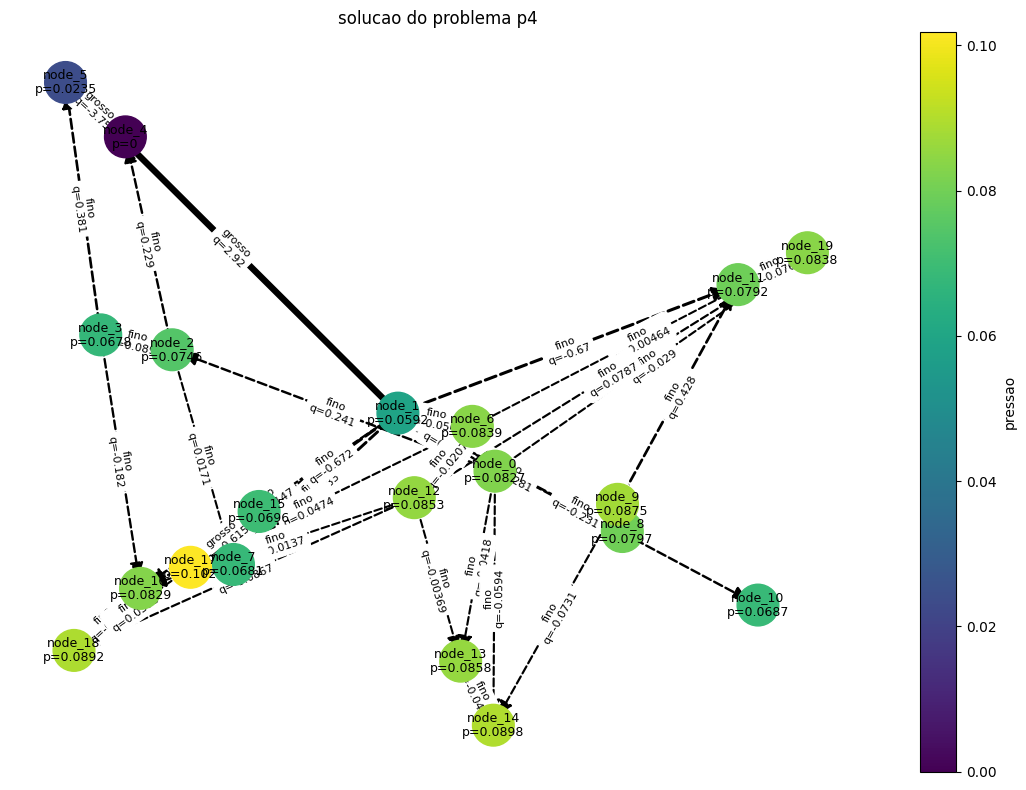

In [25]:
p4_20.plot_solution(
    layout="spring",
    figsize=(11, 8),
    show_labels=True,
)
plt.show()

## 4. Caso 2 — rede com 100 nós e poucas arestas

Este caso mantém 100 nós, mas reduz a probabilidade de conexão para controlar o número de arestas. Isso é importante porque a dificuldade do problema misto cresce fortemente com o número de variáveis binárias, isto é, com o número de arestas.

In [26]:
p1_100 = gerar_rede(
    seed=42,
    num_nodes=100,
    edge_prob=0.1,
)

mostrar_resumo_p1(p1_100, "caso 2: rede com 100 nos e poucas arestas")

caso 2: rede com 100 nos e poucas arestas
numero de nos: 100
numero de arestas: 561
pressao minima p1: 0.0 Pa
pressao maxima p1: 0.027281724666429724 Pa
amplitude de pressao p1: 0.027281724666429724 Pa


In [27]:
p4_100, baseline_100, summary_100 = resolver_caso_p4(
    p1=p1_100,
    nome="caso 2: p4 com 100 nos e poucas arestas",
    time_limit=3600,
    mip_rel_gap=1e-4,
    disp=False,
)

caso 2: p4 com 100 nos e poucas arestas
numero de arestas: 561
fracao de canos grossos: 0.1
numero de canos grossos: 57
status da solucao: viavel_nao_certificada
solucao otima certificada: False
mensagem do solver: Time limit reached. (HiGHS Status 13: Time limit reached)
gap mip: 0.32051980506016
reducao percentual da pressao maxima: 69.61956338846524 %
arestas grossas selecionadas: [('node_0', 'node_13'), ('node_0', 'node_14'), ('node_1', 'node_9'), ('node_1', 'node_76'), ('node_2', 'node_13'), ('node_4', 'node_99'), ('node_4', 'node_27'), ('node_4', 'node_67'), ('node_4', 'node_82'), ('node_5', 'node_31'), ('node_6', 'node_88'), ('node_7', 'node_64'), ('node_8', 'node_29'), ('node_8', 'node_65'), ('node_8', 'node_50'), ('node_9', 'node_99'), ('node_11', 'node_98'), ('node_11', 'node_99'), ('node_12', 'node_63'), ('node_12', 'node_83'), ('node_13', 'node_25'), ('node_13', 'node_38'), ('node_13', 'node_16'), ('node_13', 'node_18'), ('node_13', 'node_23'), ('node_13', 'node_30'), ('nod

,caso,nos,arestas,canos_grossos,pressao_minima_pa,pressao_maxima_pa,amplitude_pressao_pa
0,todos finos,100,561,0,0.0,0.027282,0.027282
1,p4 otimizado,100,561,57,0.0,0.008288,0.008288


### 4.1. Arestas escolhidas no caso de 100 nós

In [28]:
edge_rows_100 = p4_100.edge_solution_table()

if pd is not None:
    edge_df_100 = pd.DataFrame(edge_rows_100)
    display(edge_df_100.sort_values(["x_grosso", "edge"], ascending=[False, True]))
else:
    for row in edge_rows_100:
        print(row)

,edge,tipo_cano,x_grosso,area_original,area_usada,length,condutancia_usada,delta_pressao,vazao
2,"(node_0, node_13)",grosso,1,1.1841,2.3682,4.14,53.900967,0.001557,0.083911
3,"(node_0, node_14)",grosso,1,0.7995,1.5990,3.06,33.245712,-0.000167,-0.005542
32,"(node_1, node_76)",grosso,1,1.4682,2.9364,1.71,200.629348,0.000204,0.040852
20,"(node_1, node_9)",grosso,1,1.5683,3.1366,1.95,200.744569,-0.000199,-0.039908
140,"(node_11, node_98)",grosso,1,1.0838,2.1676,1.04,179.756700,-0.000489,-0.087853
...,...,...,...,...,...,...,...,...,...
555,"(node_91, node_96)",fino,0,1.7237,1.7237,1.90,62.219985,0.000239,0.014841
557,"(node_93, node_96)",fino,0,1.3894,1.3894,3.32,23.135380,0.000089,0.002065
558,"(node_94, node_97)",fino,0,0.6372,0.6372,4.51,3.582079,0.000744,0.002663
559,"(node_95, node_96)",fino,0,0.8984,0.8984,1.52,21.127886,-0.000285,-0.006029


### 4.2. Pressões nodais no caso de 100 nós

In [29]:
node_rows_100 = p4_100.node_solution_table()

if pd is not None:
    node_df_100 = pd.DataFrame(node_rows_100)
    display(node_df_100.sort_values("pressao", ascending=False))
else:
    for row in node_rows_100:
        print(row)

,node,pressao,fluxo_externo
94,node_94,0.008288,0.224047
78,node_78,0.008271,0.085683
45,node_45,0.008255,0.127882
98,node_98,0.008203,0.247706
63,node_63,0.008038,0.077641
...,...,...,...
31,node_31,0.005953,0.044835
46,node_46,0.005469,0.001343
13,node_13,0.005330,0.012085
77,node_77,0.004879,0.020104


## 5. Caso 3 — limite de tempo e retorno de solução não ótima

Este caso mostra a funcionalidade nova. O limite de tempo é colocado artificialmente muito baixo. Com isso, o solver pode parar antes de certificar otimalidade. A implementação então segue a ordem:

1. usa a solução ótima, se ela foi certificada;
2. aceita a melhor solução inteira viável retornada pelo solver, se existir;
3. se o solver não retornar solução viável, usa uma heurística baseada nas maiores quedas de pressão da rede com todos os canos finos.

O objetivo deste caso não é produzir o melhor resultado possível, mas mostrar que o notebook continua retornando uma configuração admissível.

In [30]:
p4_timeout, baseline_timeout, summary_timeout = resolver_caso_p4(
    p1=p1_100,
    nome="caso 3: limite de tempo artificialmente baixo",
    time_limit=1e-9,
    mip_rel_gap=1e-4,
    disp=False,
)

caso 3: limite de tempo artificialmente baixo
numero de arestas: 561
fracao de canos grossos: 0.1
numero de canos grossos: 57
status da solucao: heuristica
solucao otima certificada: False
mensagem do solver: Time limit reached. (HiGHS Status 13: model_status is Time limit reached; primal_status is At lower/fixed bound)
gap mip: None
reducao percentual da pressao maxima: 70.18959308211207 %
arestas grossas selecionadas: [('node_0', 'node_13'), ('node_1', 'node_31'), ('node_2', 'node_13'), ('node_2', 'node_63'), ('node_4', 'node_82'), ('node_4', 'node_87'), ('node_5', 'node_31'), ('node_6', 'node_46'), ('node_10', 'node_77'), ('node_12', 'node_27'), ('node_12', 'node_46'), ('node_13', 'node_25'), ('node_13', 'node_38'), ('node_13', 'node_16'), ('node_13', 'node_18'), ('node_13', 'node_23'), ('node_13', 'node_30'), ('node_13', 'node_42'), ('node_13', 'node_44'), ('node_13', 'node_54'), ('node_13', 'node_65'), ('node_13', 'node_73'), ('node_13', 'node_82'), ('node_13', 'node_85'), ('node_

,caso,nos,arestas,canos_grossos,pressao_minima_pa,pressao_maxima_pa,amplitude_pressao_pa
0,todos finos,100,561,0,0.0,0.027282,0.027282
1,p4 otimizado,100,561,57,0.0,0.008133,0.008133


### 5.1. Interpretação do status

A chave `solution_status` resume o tipo de solução retornada:

- `otima`: o solver certificou otimalidade global;
- `viavel_nao_certificada`: o solver parou antes da certificação, mas retornou uma solução inteira viável;
- `heuristica`: o solver não retornou solução inteira viável aproveitável e foi usada a heurística de fallback.

In [31]:
summary_timeout

{'objective_pressure_max': 0.008132793137280504,
 'solver_objective': 0.008132793137280504,
 'pressure_min': 0.0,
 'pressure_max': 0.008132793137280504,
 'pressure_range': 0.008132793137280504,
 'objective_pressure_range': 0.008132793137280504,
 'max_thick_pipes': 57,
 'n_thick_used': 57,
 'selected_thick_edges': [('node_0', 'node_13'),
  ('node_1', 'node_31'),
  ('node_2', 'node_13'),
  ('node_2', 'node_63'),
  ('node_4', 'node_82'),
  ('node_4', 'node_87'),
  ('node_5', 'node_31'),
  ('node_6', 'node_46'),
  ('node_10', 'node_77'),
  ('node_12', 'node_27'),
  ('node_12', 'node_46'),
  ('node_13', 'node_25'),
  ('node_13', 'node_38'),
  ('node_13', 'node_16'),
  ('node_13', 'node_18'),
  ('node_13', 'node_23'),
  ('node_13', 'node_30'),
  ('node_13', 'node_42'),
  ('node_13', 'node_44'),
  ('node_13', 'node_54'),
  ('node_13', 'node_65'),
  ('node_13', 'node_73'),
  ('node_13', 'node_82'),
  ('node_13', 'node_85'),
  ('node_14', 'node_77'),
  ('node_17', 'node_46'),
  ('node_18', 'nod

### 5.2. Arestas escolhidas no caso com limite de tempo

In [32]:
edge_rows_timeout = p4_timeout.edge_solution_table()

if pd is not None:
    edge_df_timeout = pd.DataFrame(edge_rows_timeout)
    display(edge_df_timeout.sort_values(["x_grosso", "edge"], ascending=[False, True]))
else:
    for row in edge_rows_timeout:
        print(row)

,edge,tipo_cano,x_grosso,area_original,area_usada,length,condutancia_usada,delta_pressao,vazao
2,"(node_0, node_13)",grosso,1,1.1841,2.3682,4.14,53.900967,0.001435,0.077359
23,"(node_1, node_31)",grosso,1,1.4864,2.9728,3.27,107.533498,0.000831,0.089402
131,"(node_10, node_77)",grosso,1,1.6259,3.2518,4.23,99.464345,0.000975,0.096976
143,"(node_12, node_27)",grosso,1,0.9790,1.9580,4.80,31.779296,0.000725,0.023046
144,"(node_12, node_46)",grosso,1,1.9259,3.8518,3.29,179.428613,0.000547,0.098196
...,...,...,...,...,...,...,...,...,...
556,"(node_92, node_97)",fino,0,0.8357,0.8357,3.15,8.821662,-0.000133,-0.001177
557,"(node_93, node_96)",fino,0,1.3894,1.3894,3.32,23.135380,0.000373,0.008632
558,"(node_94, node_97)",fino,0,0.6372,0.6372,4.51,3.582079,0.000733,0.002626
559,"(node_95, node_96)",fino,0,0.8984,0.8984,1.52,21.127886,-0.000212,-0.004479
